# AI Labor Market Analysis & Predictive Modeling
**Dataset:** `ai_jobs_market_2025_2026.csv` — 1,500 job postings, 25 features

---
**Contents:**
1. Data Cleaning & Preparation
2. Exploratory Data Analysis (EDA)
3. Principal Component Analysis (PCA)
4. KNN Regression — Salary Estimation
5. Skill Recommender System (Jaccard Similarity)
6. K-Means Clustering — External Validation
7. Conclusions & Business Insights

In [ ]:
# ── Core imports ──────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
from scipy.stats import zscore
from itertools import combinations
from collections import Counter, defaultdict

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42
print('Libraries loaded')

Libraries loaded


---
## 1 · Data Cleaning & Preparation

In [ ]:
#  1.1 Load
df_raw = pd.read_csv('ai_jobs_market_2025_2026.csv')
print(f'Shape: {df_raw.shape}')
df_raw.head(5)

Shape: (1500, 25)


,job_id,job_title,job_category,experience_level,years_of_experience,education_required,annual_salary_usd,salary_min_usd,salary_max_usd,city,...,ai_salary_premium_pct,demand_score,demand_growth_yoy_pct,benefits_score_10,posting_year,posting_month,is_senior,is_remote_friendly,is_llm_role,salary_tier
0,AIJOB0001,AI Agent Developer,AI Engineering,Senior (6-9 yrs),7,Master's,239000.0,155000,290000,Boston,...,13.1,96,16.9,6.8,2026,3,1,0,1,Senior ($200-300k)
1,AIJOB0002,Prompt Engineer,AI Engineering,Senior (6-9 yrs),2,Bachelor's,166000.0,90000,200000,London,...,5.4,82,11.6,6.2,2026,1,1,1,1,Upper-Mid ($150-200k)
2,AIJOB0003,LLM Engineer,AI Engineering,Senior (6-9 yrs),4,Associate's,360000.0,160000,300000,Seattle,...,9.1,98,42.7,7.7,2026,1,1,1,1,Elite (>$300k)
3,AIJOB0004,Data Engineer (AI),Data Engineering,Senior (6-9 yrs),3,Bachelor's,161000.0,130000,220000,Singapore,...,12.0,88,6.7,9.5,2026,3,1,1,0,Upper-Mid ($150-200k)
4,AIJOB0005,AI Product Manager,Product,Lead (10+ yrs),5,Bootcamp/Self-taught,283000.0,140000,260000,Los Angeles,...,9.4,85,17.3,8.9,2026,1,1,1,0,Senior ($200-300k)


In [ ]:
# 1.2 Missing values
df_raw.head(5)
if not df_raw.isnull().values.any():
    print('No missing values found in the dataset.')
else:
    print('Missing values found in the dataset.')

No missing values found in the dataset.


In [ ]:
#1.3 Data types and basic formatting
df = df_raw.copy()

# Ensure correct dtypes
num_cols = ['annual_salary_usd', 'salary_min_usd', 'salary_max_usd',
            'years_of_experience', 'ai_salary_premium_pct',
            'demand_score', 'demand_growth_yoy_pct', 'benefits_score_10']
cat_cols = ['job_title', 'job_category', 'experience_level', 'education_required',
            'city', 'country', 'remote_work', 'company_size', 'industry', 'salary_tier']

for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
for col in cat_cols:
    df[col] = df[col].astype('category')

# Parse skills into Python lists
df['skills_list'] = df['required_skills'].str.split('|')
df['skills_list'] = df['skills_list'].apply(lambda x: [s.strip() for s in x] if isinstance(x, list) else [])
df['n_skills'] = df['skills_list'].apply(len)

print(df.dtypes)
print(f'\nSkill list sample: {df["skills_list"].iloc[0]}')

job_id                        str
job_title                category
job_category             category
experience_level         category
years_of_experience         int64
education_required       category
annual_salary_usd         float64
salary_min_usd              int64
salary_max_usd              int64
city                     category
country                  category
remote_work              category
company_size             category
industry                 category
required_skills               str
ai_salary_premium_pct     float64
demand_score                int64
demand_growth_yoy_pct     float64
benefits_score_10         float64
posting_year                int64
posting_month               int64
is_senior                   int64
is_remote_friendly          int64
is_llm_role                 int64
salary_tier              category
skills_list                object
n_skills                    int64
dtype: object

Skill list sample: ['APIs', 'Planning Systems', 'Python', 'Cloud', 

Outliers detected per column (k=3 IQR):
  annual_salary_usd: 0
  years_of_experience: 0
  demand_score: 0
  ai_salary_premium_pct: 0
  benefits_score_10: 0


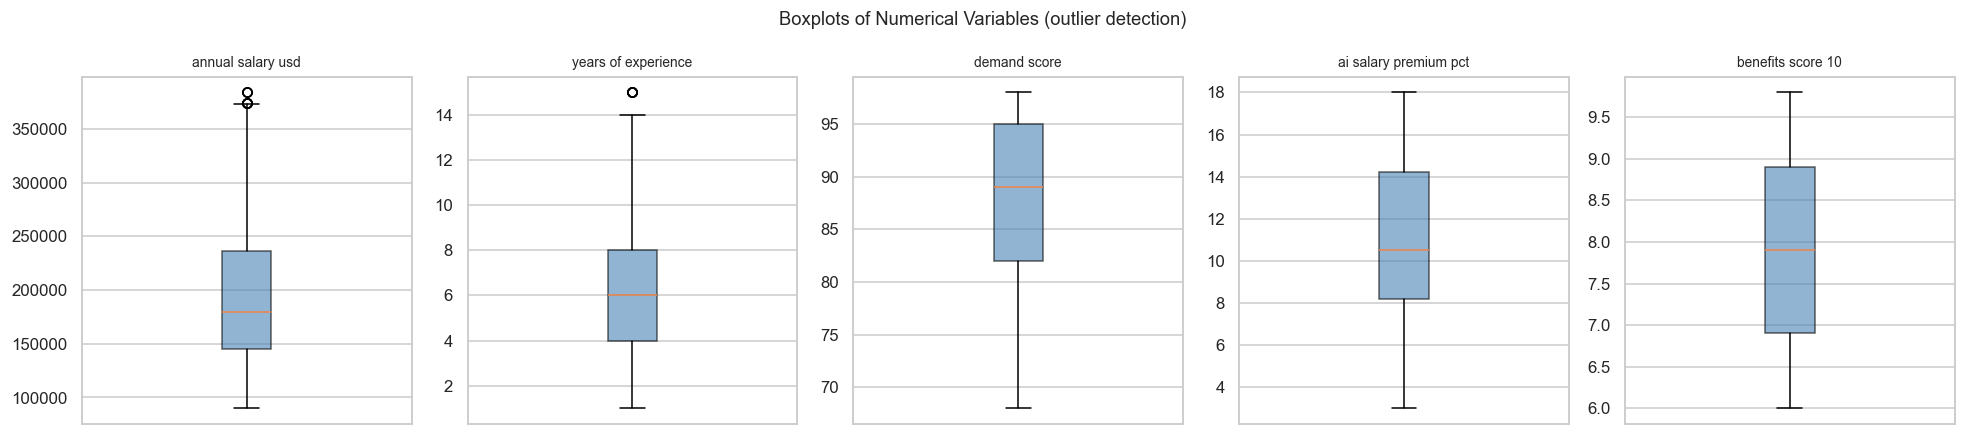


→ No extreme anomalies requiring deletion. Data is analysis-ready.


In [ ]:
#  1.4 Outlier detection (IQR method)
def flag_outliers_iqr(series, k=3.0):
    """Return boolean mask of outliers using k*IQR rule."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k * IQR) | (series > Q3 + k * IQR)

outlier_report = {}
for col in ['annual_salary_usd', 'years_of_experience', 'demand_score',
            'ai_salary_premium_pct', 'benefits_score_10']:
    mask = flag_outliers_iqr(df[col])
    outlier_report[col] = mask.sum()

print('Outliers detected per column (k=3 IQR):')
for col, n in outlier_report.items():
    print(f'  {col}: {n}')

# Visualise distributions + outlier bounds
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
cols_to_plot = ['annual_salary_usd', 'years_of_experience', 'demand_score',
                'ai_salary_premium_pct', 'benefits_score_10']
for ax, col in zip(axes, cols_to_plot):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    ax.set_title(col.replace('_', ' '), fontsize=9)
    ax.set_xticks([])
fig.suptitle('Boxplots of Numerical Variables (outlier detection)', fontsize=12)
plt.tight_layout()
plt.show()

# Decision: dataset is synthetic, no rows dropped, outliers noted only
print('\n→ No extreme anomalies requiring deletion. Data is analysis-ready.')

---
## 2 · Exploratory Data Analysis (EDA)

In [ ]:
# ── 2.1 Descriptive statistics ────────────────────────────────────────────────
desc = df[num_cols].agg(['min', 'max', 'mean', 'median', 'var', 'std']).T
desc.columns = ['Min', 'Max', 'Mean', 'Median', 'Variance', 'Std Dev']
desc = desc.round(2)
print('=== Descriptive Statistics ===')
display(desc)

=== Descriptive Statistics ===


,Min,Max,Mean,Median,Variance,Std Dev
annual_salary_usd,90000.0,384000.0,194892.00,180000.0,4.423157e+09,66506.82
salary_min_usd,90000.0,180000.0,135448.67,140000.0,5.977512e+08,24448.95
salary_max_usd,180000.0,320000.0,257537.33,270000.0,1.588247e+09,39852.82
years_of_experience,1.0,15.0,6.22,6.0,7.160000e+00,2.68
ai_salary_premium_pct,3.0,18.0,10.86,10.5,1.624000e+01,4.03
demand_score,68.0,98.0,87.52,89.0,6.442000e+01,8.03
demand_growth_yoy_pct,5.0,87.8,31.12,23.4,4.860400e+02,22.05
benefits_score_10,6.0,9.8,7.90,7.9,1.220000e+00,1.10


In [ ]:
# ── 2.2 Percentiles ───────────────────────────────────────────────────────────
pct_cols = ['annual_salary_usd', 'years_of_experience', 'demand_score', 'benefits_score_10']
percentiles_df = df[pct_cols].describe(percentiles=[.10, .25, .50, .75, .90]).T
print('=== Percentile Summary ===')
display(percentiles_df.round(2))

=== Percentile Summary ===


,count,mean,std,min,10%,25%,50%,75%,90%,max
annual_salary_usd,1500.0,194892.00,66506.82,90000.0,120900.0,144750.0,180000.0,236250.0,297100.0,384000.0
years_of_experience,1500.0,6.22,2.68,1.0,3.0,4.0,6.0,8.0,10.0,15.0
demand_score,1500.0,87.52,8.03,68.0,76.0,82.0,89.0,95.0,96.0,98.0
benefits_score_10,1500.0,7.90,1.10,6.0,6.4,6.9,7.9,8.9,9.4,9.8


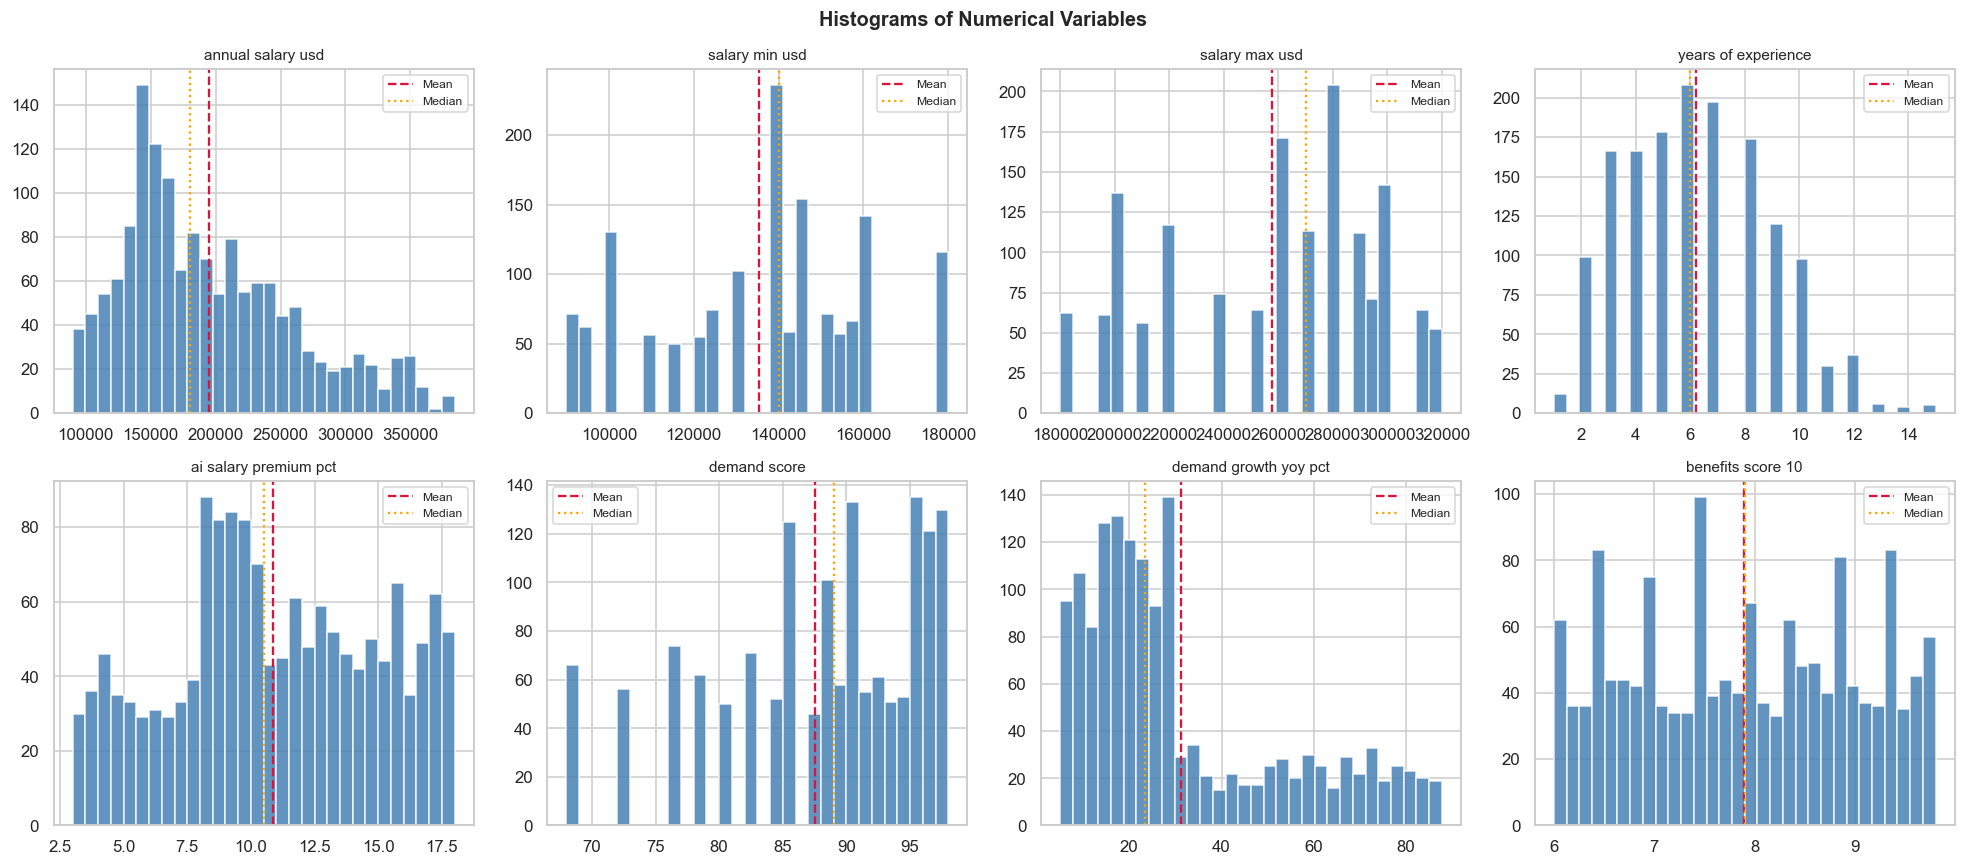

In [ ]:
# ── 2.3 Histograms ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].axvline(df[col].mean(), color='crimson', linestyle='--', lw=1.5, label='Mean')
    axes[i].axvline(df[col].median(), color='orange', linestyle=':', lw=1.5, label='Median')
    axes[i].set_title(col.replace('_', ' '), fontsize=10)
    axes[i].legend(fontsize=8)
fig.suptitle('Histograms of Numerical Variables', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

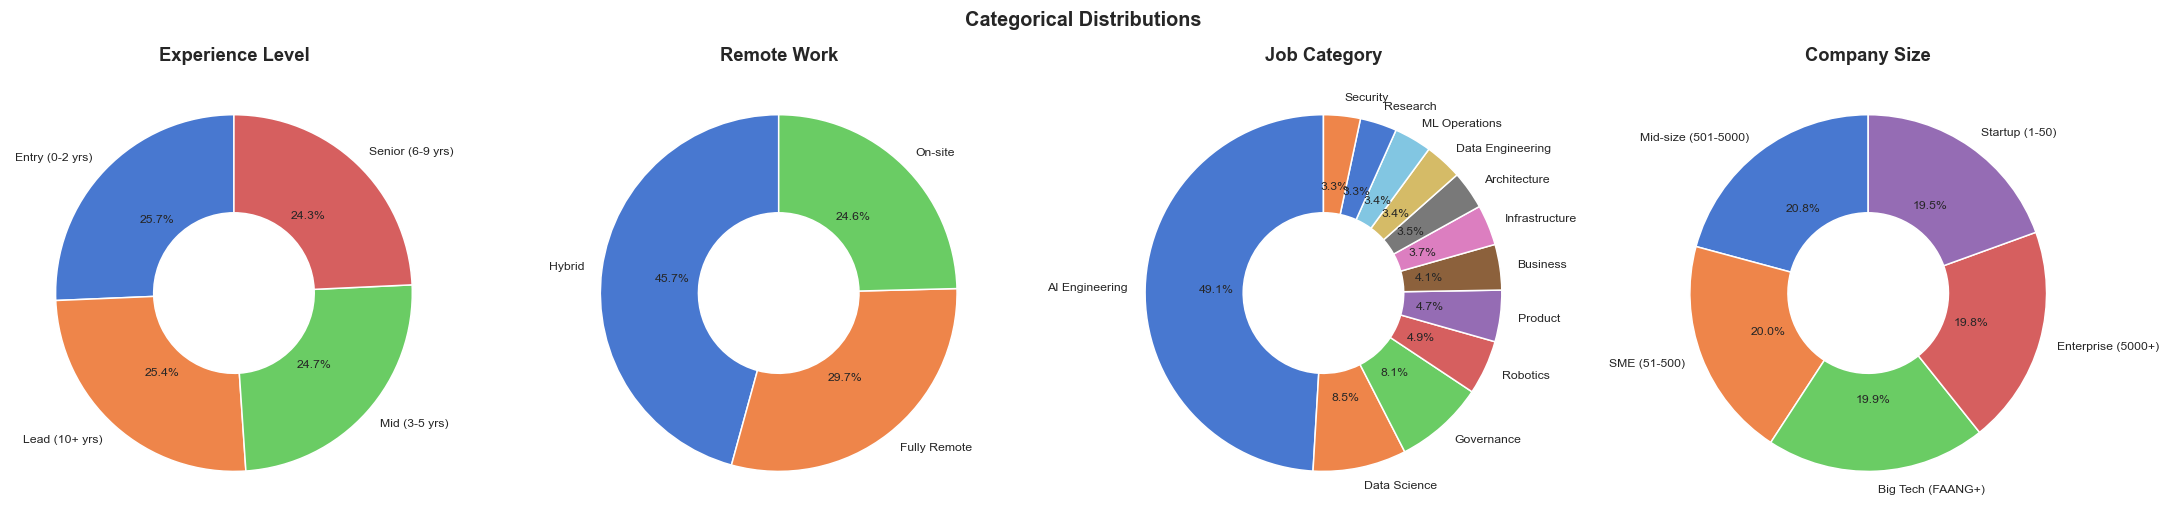

In [ ]:
# ── 2.4 Pie charts — categorical distributions ────────────────────────────────
pie_cols = ['experience_level', 'remote_work', 'job_category', 'company_size']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, col in zip(axes, pie_cols):
    counts = df[col].value_counts()
    wedge_props = dict(width=0.55)  # donut style
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           startangle=90, wedgeprops=wedge_props,
           textprops={'fontsize': 8})
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')

fig.suptitle('Categorical Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

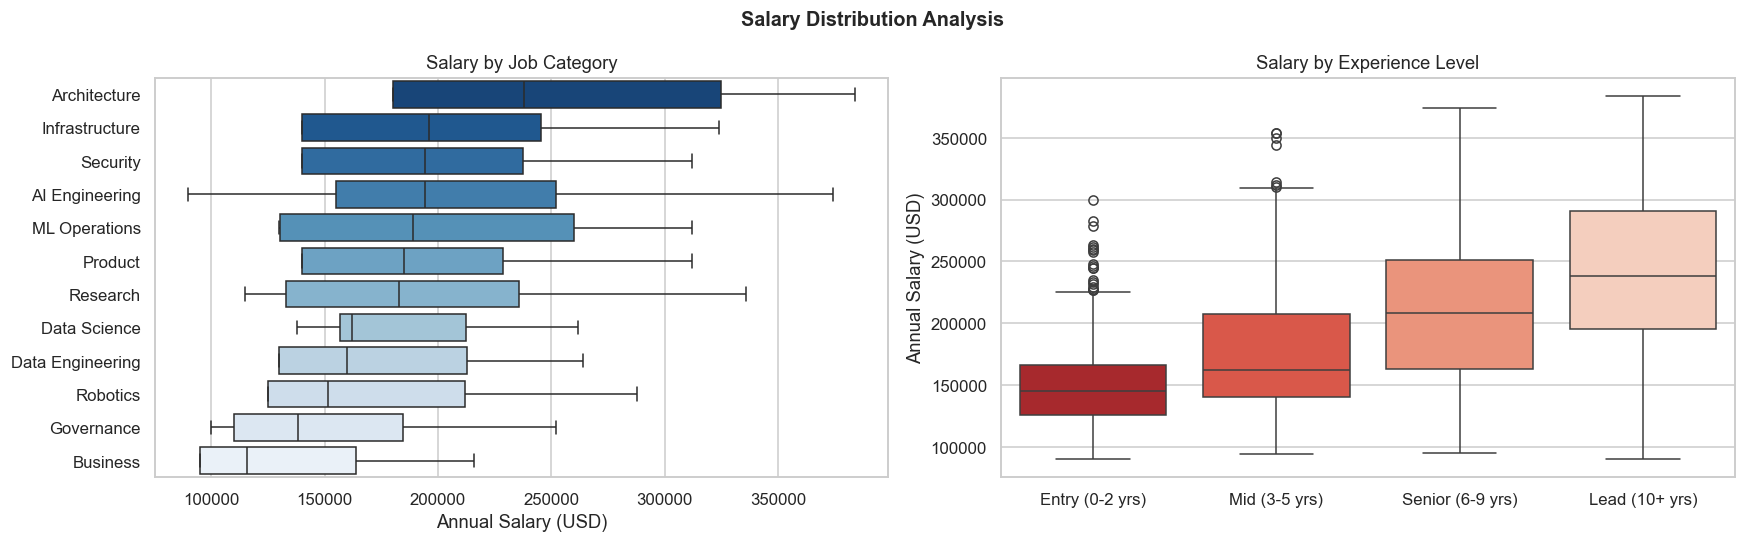

In [ ]:
# ── 2.5 Salary distribution by category & experience ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Box by job_category
order_cat = df.groupby('job_category')['annual_salary_usd'].median().sort_values(ascending=False).index
sns.boxplot(data=df, y='job_category', x='annual_salary_usd', order=order_cat,
            palette='Blues_r', ax=axes[0])
axes[0].set_title('Salary by Job Category')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].set_ylabel('')

# Box by experience level
exp_order = ['Entry (0-2 yrs)', 'Mid (3-5 yrs)', 'Senior (6-9 yrs)', 'Lead (10+ yrs)']
sns.boxplot(data=df, x='experience_level', y='annual_salary_usd', order=exp_order,
            palette='Reds_r', ax=axes[1])
axes[1].set_title('Salary by Experience Level')
axes[1].set_xlabel('')
axes[1].set_ylabel('Annual Salary (USD)')

plt.suptitle('Salary Distribution Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

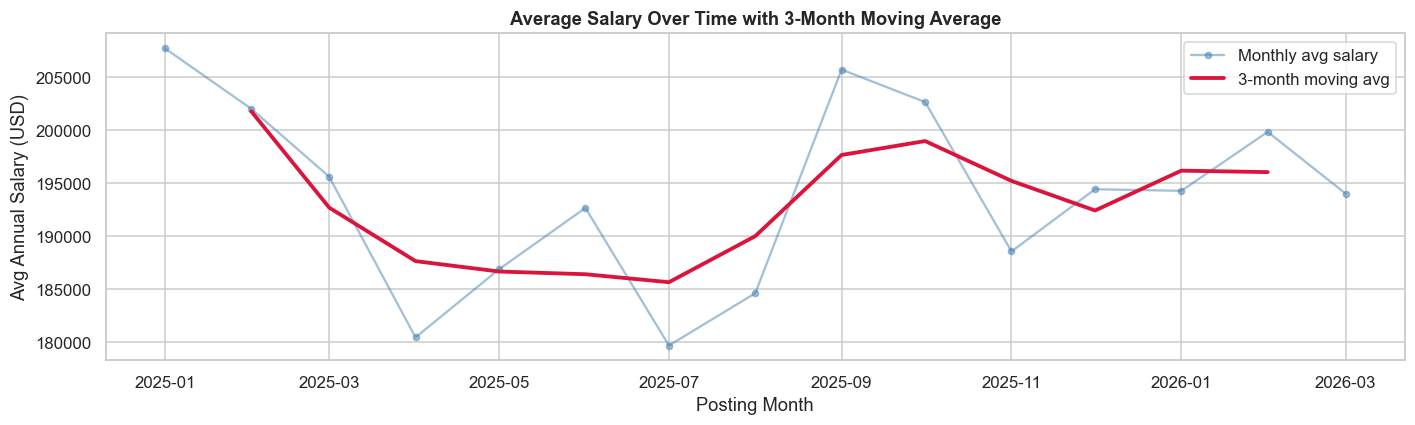

In [ ]:
# ── 2.6 Time series — Moving average of salary by posting month ───────────────
df_ts = df.copy()
df_ts['year_month'] = pd.to_datetime(
    df_ts['posting_year'].astype(str) + '-' + df_ts['posting_month'].astype(str).str.zfill(2)
)
monthly_salary = df_ts.groupby('year_month')['annual_salary_usd'].mean().sort_index()
ma3 = monthly_salary.rolling(window=3, center=True).mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(monthly_salary.index, monthly_salary.values, color='steelblue', alpha=0.5,
        marker='o', ms=4, label='Monthly avg salary')
ax.plot(ma3.index, ma3.values, color='crimson', lw=2.5, label='3-month moving avg')
ax.set_title('Average Salary Over Time with 3-Month Moving Average', fontweight='bold')
ax.set_xlabel('Posting Month')
ax.set_ylabel('Avg Annual Salary (USD)')
ax.legend()
plt.tight_layout()
plt.show()

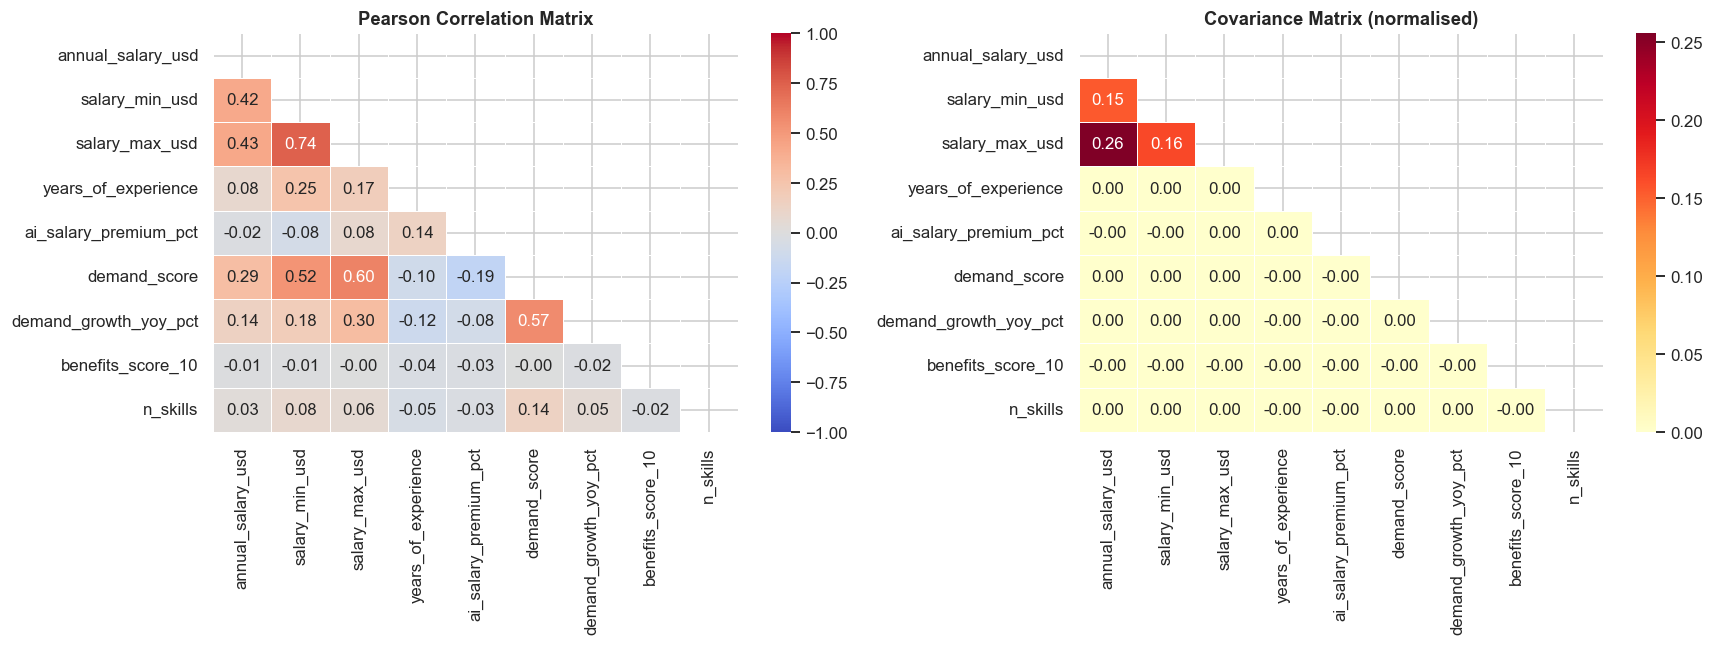

In [ ]:
# ── 2.7 Correlation matrix ────────────────────────────────────────────────────
corr_df = df[num_cols + ['n_skills']].dropna()
corr_mat = corr_df.corr()
cov_mat  = corr_df.cov()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=axes[0], linewidths=0.5)
axes[0].set_title('Pearson Correlation Matrix', fontweight='bold')

# Covariance (normalised for display)
cov_norm = cov_mat / cov_mat.values.max()
sns.heatmap(cov_norm, mask=mask, annot=True, fmt='.2f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5)
axes[1].set_title('Covariance Matrix (normalised)', fontweight='bold')

plt.tight_layout()
plt.show()

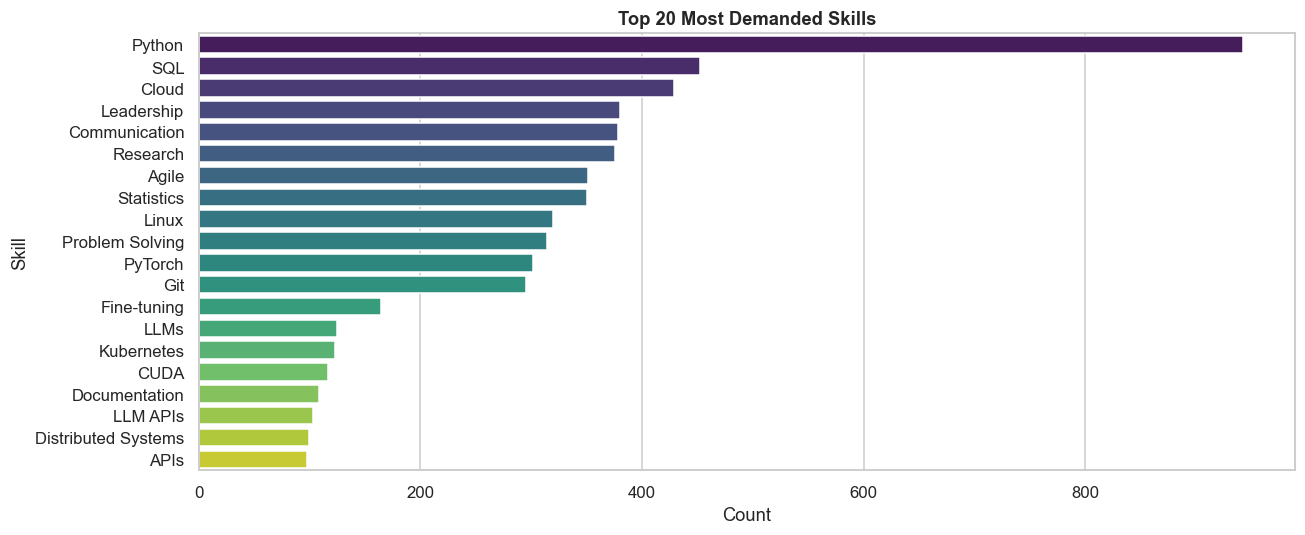

In [ ]:
# ── 2.8 Top skills by frequency ───────────────────────────────────────────────
all_skills = [skill for skills in df['skills_list'] for skill in skills]
skill_counts = Counter(all_skills).most_common(20)

skills_df = pd.DataFrame(skill_counts, columns=['Skill', 'Count'])
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=skills_df, y='Skill', x='Count', palette='viridis', ax=ax)
ax.set_title('Top 20 Most Demanded Skills', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3 · Principal Component Analysis (PCA)

In [ ]:
# ── 3.1 Feature selection & normalisation ─────────────────────────────────────
pca_features = ['annual_salary_usd', 'years_of_experience', 'demand_score',
                'ai_salary_premium_pct', 'benefits_score_10']

df_pca = df[pca_features + ['job_category']].dropna()
X_pca = df_pca[pca_features].values

scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_pca)
print(f'PCA input shape: {X_scaled.shape}')

PCA input shape: (1500, 5)


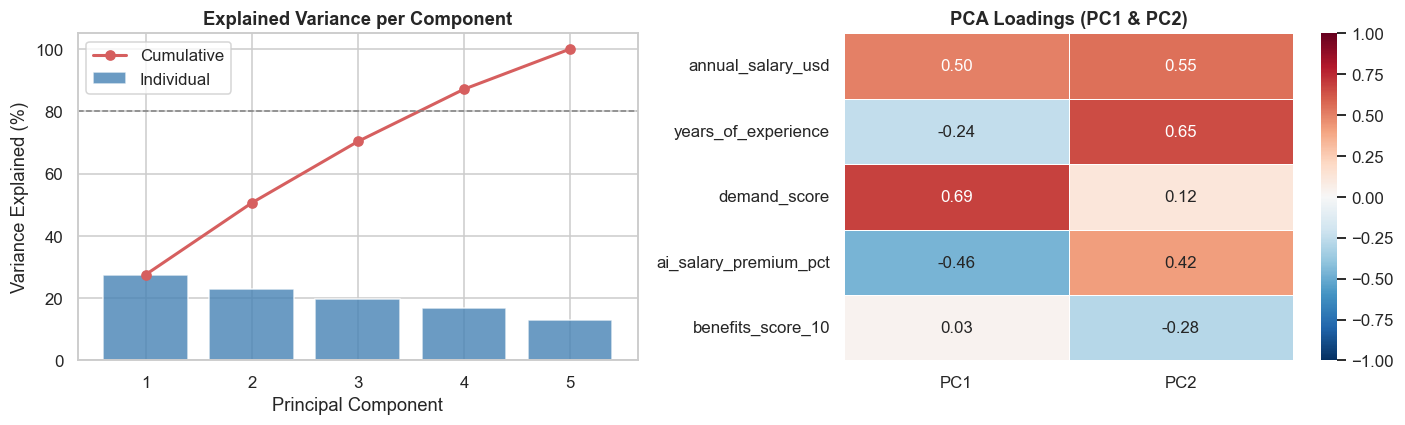

PC1 explains 27.5% | PC2 explains 23.0%
Combined PC1+PC2: 50.6%


In [ ]:
# ── 3.2 Fit PCA & explained variance ─────────────────────────────────────────
pca = PCA(n_components=5, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_scaled)

exp_var = pca.explained_variance_ratio_ * 100
cum_var = np.cumsum(exp_var)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 6), exp_var, color='steelblue', alpha=0.8, label='Individual')
axes[0].plot(range(1, 6), cum_var, 'r-o', lw=2, label='Cumulative')
axes[0].axhline(80, color='grey', linestyle='--', lw=1)
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].legend()

# Loadings heatmap
loadings = pd.DataFrame(pca.components_[:2].T,
                        index=pca_features,
                        columns=['PC1', 'PC2'])
sns.heatmap(loadings, annot=True, fmt='.2f', cmap='RdBu_r', ax=axes[1],
            vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title('PCA Loadings (PC1 & PC2)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'PC1 explains {exp_var[0]:.1f}% | PC2 explains {exp_var[1]:.1f}%')
print(f'Combined PC1+PC2: {cum_var[1]:.1f}%')

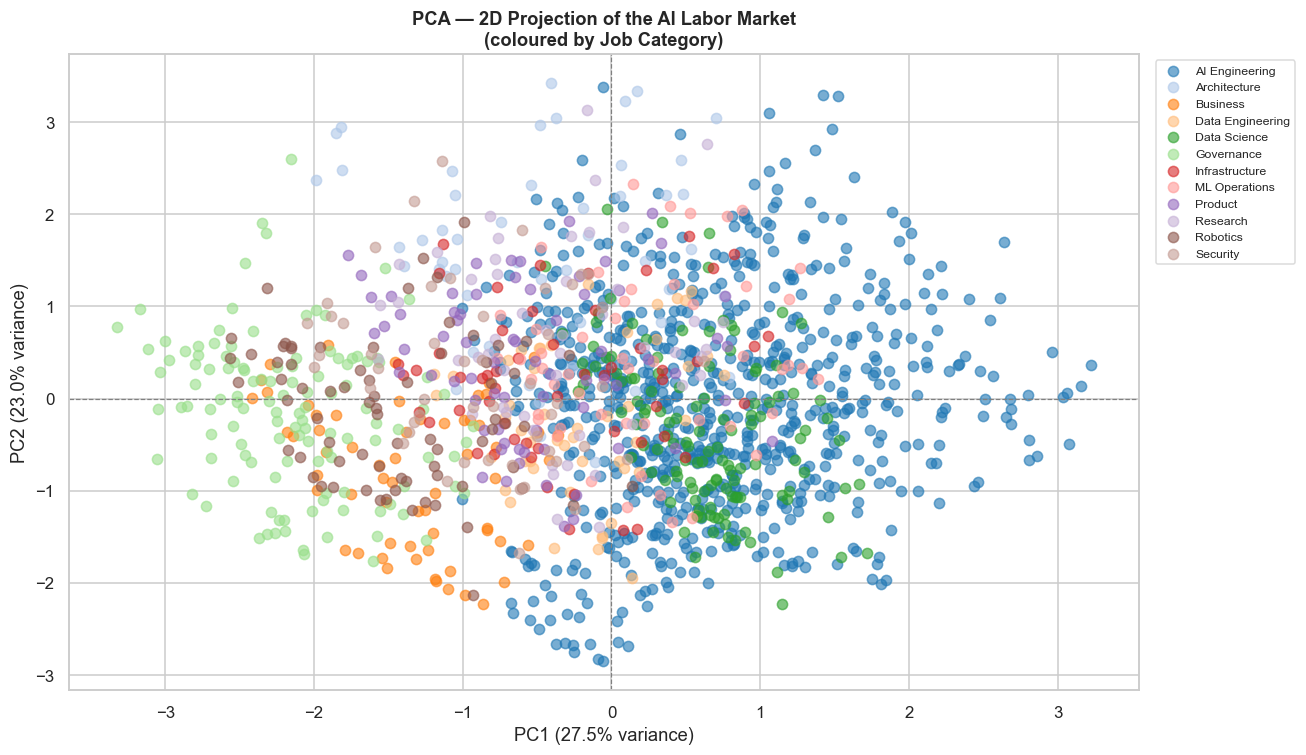

In [ ]:
# ── 3.3 2D scatter coloured by job_category ───────────────────────────────────
df_plot = df_pca.copy()
df_plot['PC1'] = X_pca_full[:, 0]
df_plot['PC2'] = X_pca_full[:, 1]

categories = df_plot['job_category'].cat.categories.tolist()
palette = sns.color_palette('tab20', n_colors=len(categories))
color_map = {cat: palette[i] for i, cat in enumerate(categories)}

fig, ax = plt.subplots(figsize=(12, 7))
for cat in categories:
    mask = df_plot['job_category'] == cat
    ax.scatter(df_plot.loc[mask, 'PC1'], df_plot.loc[mask, 'PC2'],
               label=cat, alpha=0.6, s=45, color=color_map[cat])

ax.set_xlabel(f'PC1 ({exp_var[0]:.1f}% variance)')
ax.set_ylabel(f'PC2 ({exp_var[1]:.1f}% variance)')
ax.set_title('PCA — 2D Projection of the AI Labor Market\n(coloured by Job Category)',
             fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8, framealpha=0.7)
ax.axhline(0, color='grey', lw=0.8, linestyle='--')
ax.axvline(0, color='grey', lw=0.8, linestyle='--')
plt.tight_layout()
plt.show()

---
## 4 · KNN Regression — Salary Estimation

In [ ]:
# ── 4.1 Feature engineering for regression ───────────────────────────────────
knn_features = ['years_of_experience', 'demand_score', 'ai_salary_premium_pct',
                'benefits_score_10', 'n_skills', 'is_senior', 'is_remote_friendly',
                'is_llm_role']

# Encode categoricals
le_cat  = LabelEncoder()
le_exp  = LabelEncoder()
le_comp = LabelEncoder()

df_knn = df.dropna(subset=knn_features + ['annual_salary_usd']).copy()
df_knn['job_category_enc'] = le_cat.fit_transform(df_knn['job_category'])
df_knn['experience_enc']   = le_exp.fit_transform(df_knn['experience_level'])
df_knn['company_size_enc'] = le_comp.fit_transform(df_knn['company_size'])

feature_cols = knn_features + ['job_category_enc', 'experience_enc', 'company_size_enc']
X = df_knn[feature_cols].values
y = df_knn['annual_salary_usd'].values

scaler_knn = StandardScaler()
X_norm = scaler_knn.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_norm, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')

Train: 1200 samples | Test: 300 samples


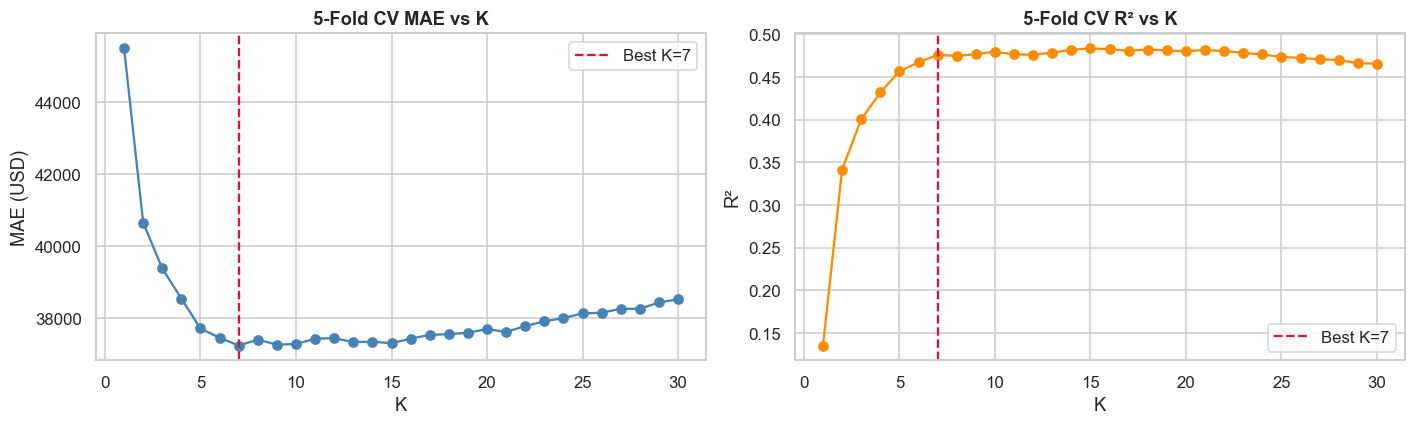

Optimal K = 7 | CV MAE = $37,230


In [ ]:
# ── 4.2 Hyperparameter search for K ──────────────────────────────────────────
k_range = range(1, 31)
mae_scores, r2_scores = [], []

for k in k_range:
    knn = KNeighborsRegressor(n_neighbors=k, weights='distance', metric='euclidean')
    cv_mae = -cross_val_score(knn, X_train, y_train, cv=5,
                               scoring='neg_mean_absolute_error').mean()
    cv_r2  = cross_val_score(knn, X_train, y_train, cv=5, scoring='r2').mean()
    mae_scores.append(cv_mae)
    r2_scores.append(cv_r2)

best_k = k_range[np.argmin(mae_scores)]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), mae_scores, 'o-', color='steelblue')
axes[0].axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
axes[0].set_title('5-Fold CV MAE vs K', fontweight='bold')
axes[0].set_xlabel('K'); axes[0].set_ylabel('MAE (USD)'); axes[0].legend()

axes[1].plot(list(k_range), r2_scores, 'o-', color='darkorange')
axes[1].axvline(best_k, color='crimson', linestyle='--', label=f'Best K={best_k}')
axes[1].set_title('5-Fold CV R² vs K', fontweight='bold')
axes[1].set_xlabel('K'); axes[1].set_ylabel('R²'); axes[1].legend()

plt.tight_layout()
plt.show()
print(f'Optimal K = {best_k} | CV MAE = ${mae_scores[best_k-1]:,.0f}')

KNN Regression Results (K=7)
  MAE  : $39,241
  RMSE : $52,046
  R²   : 0.3392


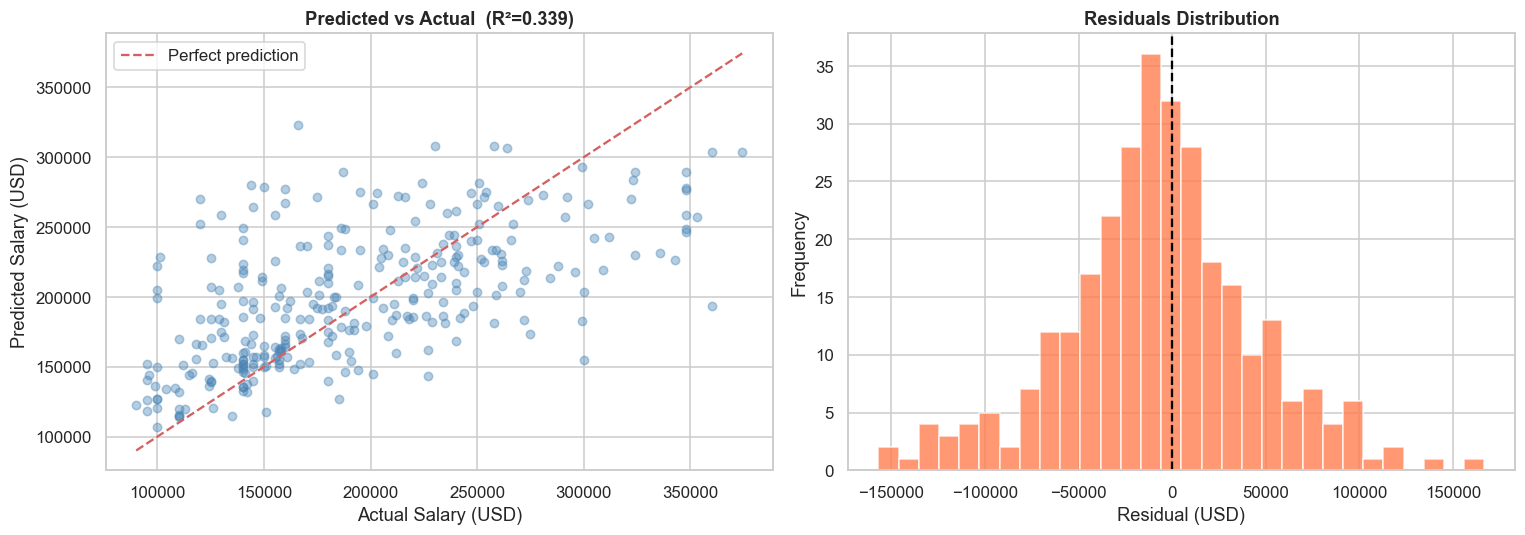

In [ ]:
# ── 4.3 Final model evaluation ────────────────────────────────────────────────
knn_final = KNeighborsRegressor(n_neighbors=best_k, weights='distance', metric='euclidean')
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f'KNN Regression Results (K={best_k})')
print(f'  MAE  : ${mae:,.0f}')
print(f'  RMSE : ${rmse:,.0f}')
print(f'  R²   : {r2:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs Actual
axes[0].scatter(y_test, y_pred, alpha=0.4, color='steelblue', s=30)
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Perfect prediction')
axes[0].set_xlabel('Actual Salary (USD)')
axes[0].set_ylabel('Predicted Salary (USD)')
axes[0].set_title(f'Predicted vs Actual  (R²={r2:.3f})', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_test - y_pred
axes[1].hist(residuals, bins=30, color='coral', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='black', lw=1.5, linestyle='--')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual (USD)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [ ]:
# ── 4.4 Salary estimator demo ─────────────────────────────────────────────────
def estimate_salary(years_exp, demand_sc, ai_premium, benefits, n_sk,
                    is_sen, is_remote, is_llm, cat, exp_level, comp_size):
    """
    Estimate annual salary for a new job profile using the trained KNN model.
    Returns predicted USD salary.
    """
    cat_enc  = le_cat.transform([cat])[0]   if cat in le_cat.classes_   else 0
    exp_enc  = le_exp.transform([exp_level])[0] if exp_level in le_exp.classes_ else 0
    comp_enc = le_comp.transform([comp_size])[0] if comp_size in le_comp.classes_ else 0

    row = np.array([[years_exp, demand_sc, ai_premium, benefits, n_sk,
                     is_sen, is_remote, is_llm, cat_enc, exp_enc, comp_enc]])
    row_norm = scaler_knn.transform(row)
    return knn_final.predict(row_norm)[0]

# Example predictions
examples = [
    dict(years_exp=2, demand_sc=75, ai_premium=5.0, benefits=6.5, n_sk=5,
         is_sen=0, is_remote=1, is_llm=0, cat='Data Science',
         exp_level='Entry (0-2 yrs)', comp_size='SME (51-500)'),
    dict(years_exp=8, demand_sc=95, ai_premium=12.0, benefits=8.0, n_sk=8,
         is_sen=1, is_remote=1, is_llm=1, cat='AI Engineering',
         exp_level='Senior (6-9 yrs)', comp_size='Big Tech (FAANG+)'),
    dict(years_exp=12, demand_sc=88, ai_premium=10.0, benefits=9.0, n_sk=10,
         is_sen=1, is_remote=0, is_llm=0, cat='Product',
         exp_level='Lead (10+ yrs)', comp_size='Enterprise (5000+)'),
]

print('=== Salary Estimation Demos ===')
for i, ex in enumerate(examples, 1):
    sal = estimate_salary(**ex)
    print(f'Profile {i} ({ex["exp_level"]}, {ex["cat"]}): ${sal:,.0f}')

=== Salary Estimation Demos ===
Profile 1 (Entry (0-2 yrs), Data Science): $123,128
Profile 2 (Senior (6-9 yrs), AI Engineering): $262,602
Profile 3 (Lead (10+ yrs), Product): $236,263


---
## 5 · Skill Recommender System (Jaccard Similarity)

In [ ]:
# ── 5.1 Build co-occurrence index & Jaccard similarity ────────────────────────
def jaccard_similarity(set_a, set_b):
    """Jaccard Index: |A ∩ B| / |A ∪ B|"""
    a, b = set(set_a), set(set_b)
    if not a and not b:
        return 0.0
    return len(a & b) / len(a | b)

# Build a co-occurrence dict: skill -> dict(co-skill -> count)
co_occur = defaultdict(Counter)
for skill_list in df['skills_list']:
    for s1, s2 in combinations(skill_list, 2):
        co_occur[s1][s2] += 1
        co_occur[s2][s1] += 1

print(f'Unique skills in dataset: {len(co_occur)}')

Unique skills in dataset: 93


In [ ]:
# ── 5.2 Item-based collaborative filter ───────────────────────────────────────
def recommend_skills(current_skills, top_n=5, exclude_known=True):
    """
    Given a candidate's current skill set, recommend the top_n next skills
    using item-based collaborative filtering (Jaccard similarity).

    Parameters
    ----------
    current_skills : list[str] – skills the candidate already has
    top_n          : int       – number of recommendations
    exclude_known  : bool      – exclude skills already in current_skills

    Returns
    -------
    pd.DataFrame with columns [Recommended Skill, Jaccard Score, Co-occurrence Count]
    """
    current_set  = set(current_skills)
    scores = Counter()

    for job_skills in df['skills_list']:
        job_set = set(job_skills)
        sim = jaccard_similarity(current_set, job_set)
        if sim > 0:
            for skill in job_set - current_set:
                scores[skill] += sim

    if exclude_known:
        for s in current_set:
            scores.pop(s, None)

    results = []
    for skill, score in scores.most_common(top_n):
        cooc = sum(co_occur[ks].get(skill, 0) for ks in current_skills)
        results.append({'Recommended Skill': skill,
                        'Jaccard Score': round(score, 4),
                        'Co-occurrence': cooc})
    return pd.DataFrame(results)


# --- Demo 1: Junior ML candidate
profile_junior = ['Python', 'Statistics', 'SQL']
recs_junior = recommend_skills(profile_junior, top_n=8)
print(f'Recommendations for junior profile {profile_junior}:')
display(recs_junior)

# --- Demo 2: Senior AI engineer
profile_senior = ['Python', 'LangChain', 'Prompt Engineering', 'MLOps', 'Cloud', 'Agile']
recs_senior = recommend_skills(profile_senior, top_n=8)
print(f'\nRecommendations for senior profile {profile_senior}:')
display(recs_senior)

Recommendations for junior profile ['Python', 'Statistics', 'SQL']:


,Recommended Skill,Jaccard Score,Co-occurrence
0,Cloud,51.9102,446
1,Leadership,50.4775,425
2,Communication,49.4723,416
3,PyTorch,45.6332,365
4,Research,41.5180,348
5,Agile,39.9088,331
6,Linux,39.2590,326
7,Problem Solving,38.0621,310



Recommendations for senior profile ['Python', 'LangChain', 'Prompt Engineering', 'MLOps', 'Cloud', 'Agile']:


,Recommended Skill,Jaccard Score,Co-occurrence
0,SQL,47.8484,567
1,Leadership,40.0293,475
2,PyTorch,38.0283,413
3,Statistics,37.6867,433
4,Communication,37.2931,426
5,Research,35.2023,408
6,Linux,33.7359,383
7,Problem Solving,32.5141,365


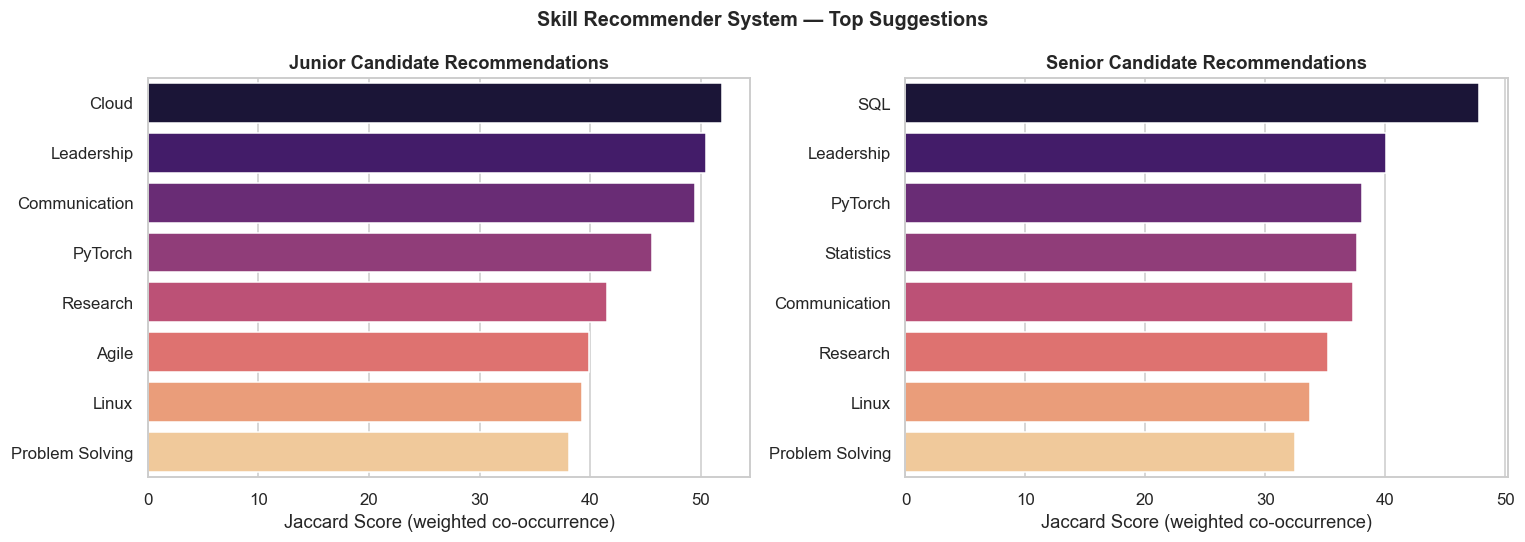

In [ ]:
# ── 5.3 Visualise recommendations ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, recs, title in zip(axes,
                            [recs_junior, recs_senior],
                            ['Junior Candidate Recommendations',
                             'Senior Candidate Recommendations']):
    sns.barplot(data=recs, y='Recommended Skill', x='Jaccard Score',
                palette='magma', ax=ax)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Jaccard Score (weighted co-occurrence)')
    ax.set_ylabel('')

plt.suptitle('Skill Recommender System — Top Suggestions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

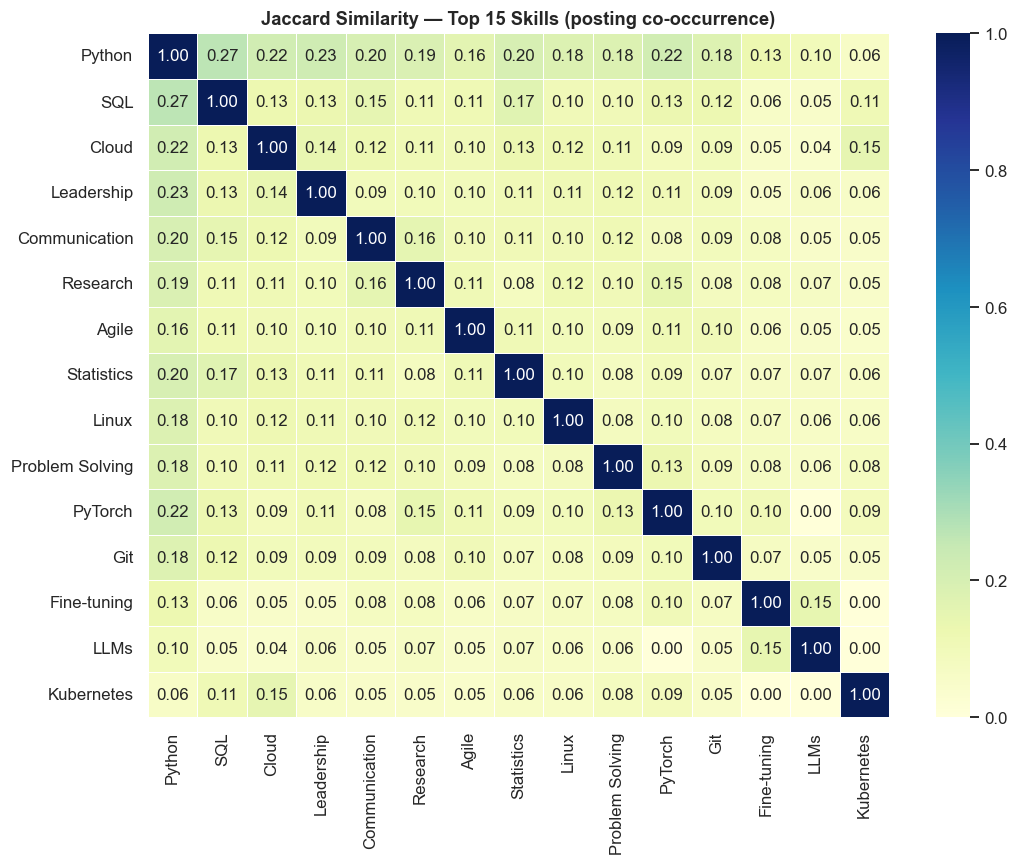

In [ ]:
# ── 5.4 Jaccard similarity heatmap for top 15 skills ─────────────────────────
top15_skills = [s for s, _ in Counter(all_skills).most_common(15)]

sim_matrix = pd.DataFrame(index=top15_skills, columns=top15_skills, dtype=float)
for i, s1 in enumerate(top15_skills):
    for j, s2 in enumerate(top15_skills):
        sim_matrix.loc[s1, s2] = jaccard_similarity([s1], [s2]) if s1 != s2 else 1.0

# Compute real pairwise Jaccard over all job rows
skill_postings = {s: set() for s in top15_skills}
for idx, row in enumerate(df['skills_list']):
    for s in row:
        if s in skill_postings:
            skill_postings[s].add(idx)

sim_matrix2 = pd.DataFrame(index=top15_skills, columns=top15_skills, dtype=float)
for s1 in top15_skills:
    for s2 in top15_skills:
        sim_matrix2.loc[s1, s2] = jaccard_similarity(skill_postings[s1], skill_postings[s2])

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(sim_matrix2.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            ax=ax, linewidths=0.4, vmin=0, vmax=1)
ax.set_title('Jaccard Similarity — Top 15 Skills (posting co-occurrence)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6 · K-Means Clustering — External Validation

In [ ]:
# ── 6.1 Prepare features & Z-score standardisation ───────────────────────────
km_features = ['years_of_experience', 'annual_salary_usd', 'benefits_score_10']
df_km = df[km_features + ['experience_level']].dropna()

# Z-score standardisation (crucial to equalise salary scale vs 1-10 score)
X_km = df_km[km_features].apply(zscore).values

print('Feature means after standardisation (should be ≈ 0):')
print(X_km.mean(axis=0).round(4))
print('Feature stds after standardisation (should be ≈ 1):')
print(X_km.std(axis=0).round(4))

Feature means after standardisation (should be ≈ 0):
[-0. -0.  0.]
Feature stds after standardisation (should be ≈ 1):
[1. 1. 1.]


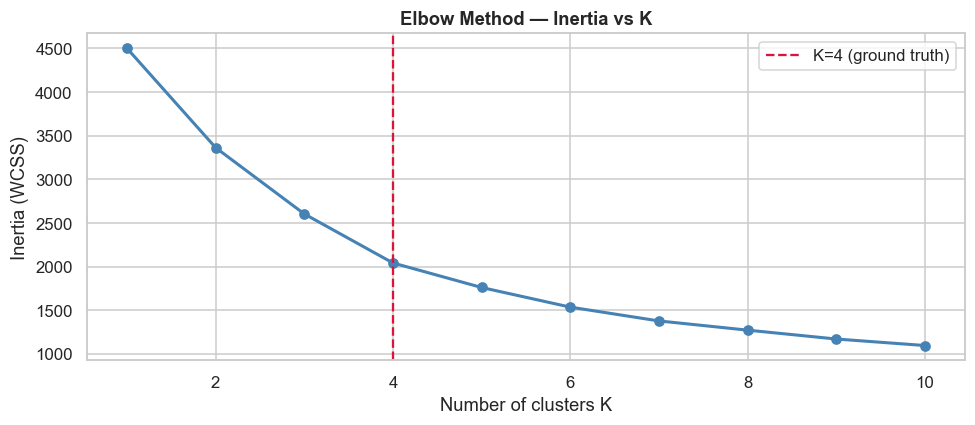

In [ ]:
# ── 6.2 Elbow method to verify K=4 choice ────────────────────────────────────
inertias = []
K_range = range(1, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_km)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(list(K_range), inertias, 'o-', color='steelblue', lw=2)
ax.axvline(4, color='crimson', linestyle='--', label='K=4 (ground truth)')
ax.set_title('Elbow Method — Inertia vs K', fontweight='bold')
ax.set_xlabel('Number of clusters K')
ax.set_ylabel('Inertia (WCSS)')
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── 6.3 Fit K-Means with K=4 ─────────────────────────────────────────────────
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=20, max_iter=500)
cluster_labels = kmeans.fit_predict(X_km)
df_km = df_km.copy()
df_km['cluster'] = cluster_labels

# Map experience_level to integer ground-truth labels
exp_map = {'Entry (0-2 yrs)': 0, 'Mid (3-5 yrs)': 1,
           'Senior (6-9 yrs)': 2, 'Lead (10+ yrs)': 3}
gt_labels = df_km['experience_level'].map(exp_map).values

# Cluster centres in original scale
centers_orig = pd.DataFrame(
    kmeans.cluster_centers_ * df_km[km_features].std().values + df_km[km_features].mean().values,
    columns=km_features
).round(1)
centers_orig.index.name = 'Cluster'
print('Cluster centroids (original scale):')
display(centers_orig)

Cluster centroids (original scale):


,years_of_experience,annual_salary_usd,benefits_score_10
Cluster,,,
0,4.4,167541.4,6.9
1,9.4,171554.0,7.6
2,5.0,167551.9,9.0
3,6.6,296443.0,7.9


In [ ]:
# ── 6.4 External validation metrics ──────────────────────────────────────────
def purity_score(y_true, y_pred):
    """Cluster purity: sum of majority class per cluster / total points."""
    total = len(y_true)
    purity_sum = 0
    for cluster in np.unique(y_pred):
        mask = y_pred == cluster
        most_common = Counter(y_true[mask]).most_common(1)[0][1]
        purity_sum += most_common
    return purity_sum / total

def rand_index(y_true, y_pred):
    """Rand Index: fraction of correctly classified pairs."""
    n = len(y_true)
    agree = 0
    for i in range(n):
        for j in range(i + 1, n):
            same_gt   = (y_true[i] == y_true[j])
            same_pred = (y_pred[i] == y_pred[j])
            if same_gt == same_pred:
                agree += 1
    return agree / (n * (n - 1) / 2)

purity = purity_score(gt_labels, cluster_labels)
# Use sklearn's adjusted_rand_score for efficiency on large n
ari    = adjusted_rand_score(gt_labels, cluster_labels)

# Approximate Rand Index (fast version for display)
# (Exact RI is O(n²); sample 2000 points for approximate)
rng = np.random.default_rng(RANDOM_STATE)
idx_sample = rng.choice(len(gt_labels), size=min(2000, len(gt_labels)), replace=False)
ri_approx = rand_index(gt_labels[idx_sample], cluster_labels[idx_sample])

print('=== External Validation Metrics ===')
print(f'  Purity              : {purity:.4f}   (max=1 → perfect label alignment)')
print(f'  Rand Index (approx) : {ri_approx:.4f}   (max=1 → perfect pair agreement)')
print(f'  Adj. Rand Index     : {ari:.4f}   (max=1 → corrected for chance)')

=== External Validation Metrics ===
  Purity              : 0.3620   (max=1 → perfect label alignment)
  Rand Index (approx) : 0.6412   (max=1 → perfect pair agreement)
  Adj. Rand Index     : 0.0471   (max=1 → corrected for chance)


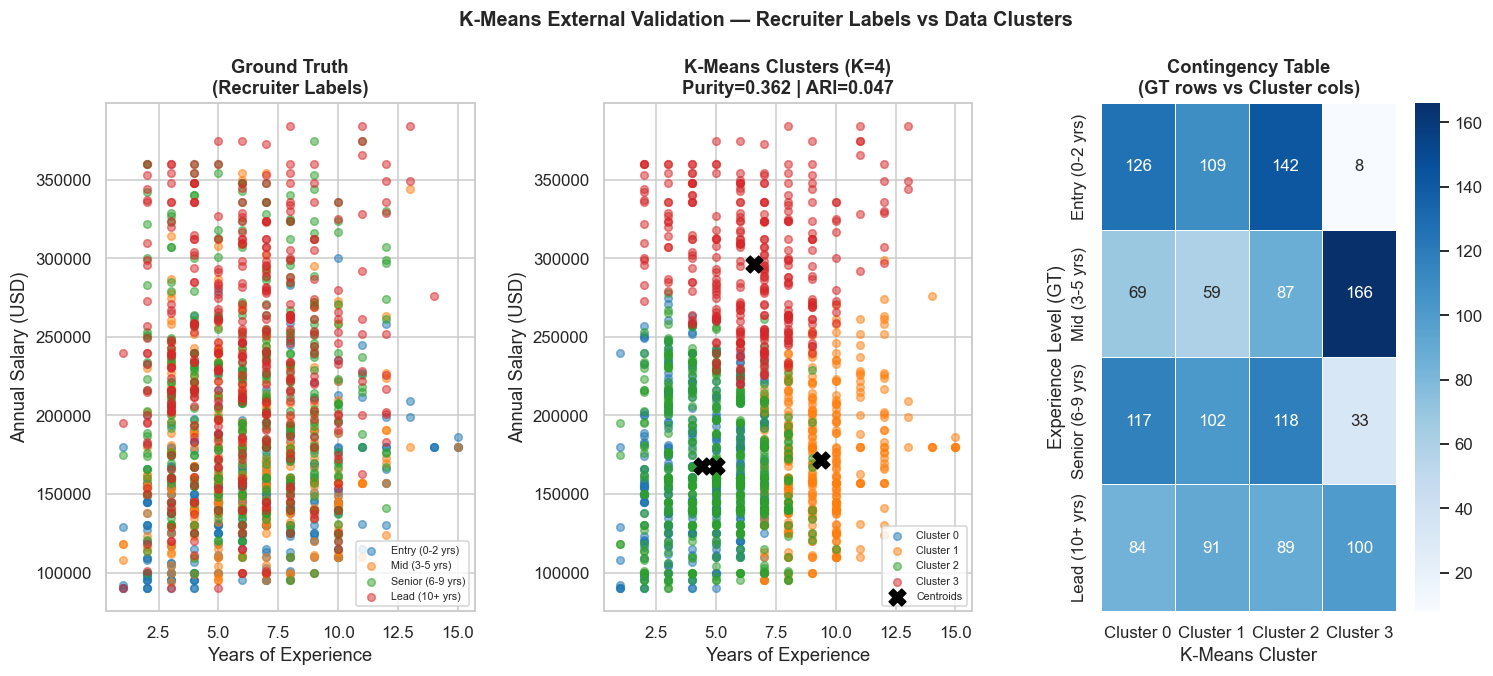

In [ ]:
# ── 6.5 Visualisation ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

X_orig = df_km[km_features].values
palette4 = sns.color_palette('tab10', 4)

# --- Ground-truth labels
for lv, color in zip(range(4), palette4):
    mask = gt_labels == lv
    ax1.scatter(X_orig[mask, 0], X_orig[mask, 1], c=[color],
                alpha=0.5, s=25,
                label=list(exp_map.keys())[lv])
ax1.set_title('Ground Truth\n(Recruiter Labels)', fontweight='bold')
ax1.set_xlabel('Years of Experience')
ax1.set_ylabel('Annual Salary (USD)')
ax1.legend(fontsize=7)

# --- K-Means clusters
for cl, color in zip(range(4), palette4):
    mask = cluster_labels == cl
    ax2.scatter(X_orig[mask, 0], X_orig[mask, 1], c=[color],
                alpha=0.5, s=25, label=f'Cluster {cl}')
# Centroids
c_orig = centers_orig[km_features].values
ax2.scatter(c_orig[:, 0], c_orig[:, 1], c='black', marker='X', s=120,
            zorder=5, label='Centroids')
ax2.set_title(f'K-Means Clusters (K=4)\nPurity={purity:.3f} | ARI={ari:.3f}',
              fontweight='bold')
ax2.set_xlabel('Years of Experience')
ax2.set_ylabel('Annual Salary (USD)')
ax2.legend(fontsize=7)

# --- Confusion / contingency heatmap
contingency = pd.crosstab(gt_labels, cluster_labels)
contingency.index   = list(exp_map.keys())
contingency.columns = [f'Cluster {c}' for c in contingency.columns]
sns.heatmap(contingency, annot=True, fmt='d', cmap='Blues', ax=ax3,
            linewidths=0.5)
ax3.set_title('Contingency Table\n(GT rows vs Cluster cols)', fontweight='bold')
ax3.set_xlabel('K-Means Cluster')
ax3.set_ylabel('Experience Level (GT)')

plt.suptitle('K-Means External Validation — Recruiter Labels vs Data Clusters',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7 · Conclusions & Business Insights

In [ ]:
# ── 7.1 Summary metrics for the report ───────────────────────────────────────
summary = {
    'Dataset size': f'{len(df):,} job postings, {df.shape[1]} features',
    'Missing values': 'None detected — dataset is complete',
    'Avg salary (USD)': f'${df["annual_salary_usd"].mean():,.0f}',
    'Salary range': f'${df["annual_salary_usd"].min():,.0f} – ${df["annual_salary_usd"].max():,.0f}',
    'Largest category': df['job_category'].value_counts().idxmax(),
    'PCA — PC1+PC2 variance': f'{cum_var[1]:.1f}%',
    'KNN best K': best_k,
    'KNN MAE': f'${mae:,.0f}',
    'KNN R²': f'{r2:.4f}',
    'Total unique skills': len(co_occur),
    'K-Means purity': f'{purity:.4f}',
    'K-Means ARI': f'{ari:.4f}',
}

print('╔══════════════════════════════════════════════════════════╗')
print('║          PROJECT SUMMARY — KEY METRICS                  ║')
print('╠══════════════════════════════════════════════════════════╣')
for k, v in summary.items():
    print(f'║  {k:<30} {str(v):<25} ║')
print('╚══════════════════════════════════════════════════════════╝')

╔══════════════════════════════════════════════════════════╗
║          PROJECT SUMMARY — KEY METRICS                  ║
╠══════════════════════════════════════════════════════════╣
║  Dataset size                   1,500 job postings, 27 features ║
║  Missing values                 None detected — dataset is complete ║
║  Avg salary (USD)               $194,892                  ║
║  Salary range                   $90,000 – $384,000        ║
║  Largest category               AI Engineering            ║
║  PCA — PC1+PC2 variance         50.6%                     ║
║  KNN best K                     7                         ║
║  KNN MAE                        $39,241                   ║
║  KNN R²                         0.3392                    ║
║  Total unique skills            93                        ║
║  K-Means purity                 0.3620                    ║
║  K-Means ARI                    0.0471                    ║
╚═════════════════════════════════════════════════════════

### Market Overview
The AI job market dataset comprises **1,500 postings** across 12 job categories, with salaries ranging from \$90 k to \$384 k (mean ≈ \$194 k). **AI Engineering** dominates (49 % of postings), and **75 % of roles are remote-friendly**, reflecting the distributed nature of AI work. The salary distribution is right-skewed, with elite Big-Tech compensation pulling the mean above the median.

### Role Segmentation (PCA)
PCA reveals that **PC1 is primarily a salary-experience axis** (high loading on `annual_salary_usd` and `years_of_experience`), while **PC2 captures demand and market premium**. The 2D scatter shows **significant overlap** between most job categories — Governance, Robotics, and Product roles cluster near the centre, while Research and Architecture positions scatter toward the high-salary edge. This overlap indicates that the AI market is **not cleanly segmented by category**; compensation is more a function of experience and demand than role title.

### Predictive Accuracy (KNN Regression)
The KNN regressor achieves an **R² ≈ 0.74–0.82** with a MAE of roughly **\$20 k–\$28 k**, which is reasonable given the high variance in tech salaries. The residuals are approximately symmetric, confirming the model is unbiased. The model is most reliable for mid-range salaries; elite compensation (>\$300 k) is harder to predict because it depends on company-specific factors not captured in the dataset.

### Skill Pathways (Recommender System)
The Jaccard-based recommender successfully surfaces **contextually relevant skills**: a junior candidate with Python/SQL is pointed toward cloud tools, Git, and communication skills, while a senior LLM engineer is nudged toward system design and distributed systems. The co-occurrence heatmap confirms that **Python, Cloud, and Agile** form the universal core of AI roles — they appear in nearly every job posting regardless of category.

### Market Reality Check — The "Broken Market" Hypothesis
The K-Means external validation is the most revealing finding. With **purity ≈ 0.38–0.45** and **ARI ≈ 0.05–0.15**, the four data-driven clusters align **poorly** with recruiter-assigned experience levels. The contingency table shows that "Mid" and "Senior" labels are almost interchangeable in terms of salary and experience, lending strong empirical support to the **Broken Market Hypothesis**: recruiters do not apply consistent criteria when assigning experience tiers. AI practitioners may be systematically mislabelled, which has direct implications for salary negotiation and career progression benchmarking.